
# Descriptive Statistics — Full Industry Analysis Notebook

This notebook demonstrates how to apply **all descriptive statistics concepts** using a realistic **Retail Sales Dataset** with **NumPy, Pandas, Matplotlib, and Seaborn**.

Concepts Covered:

1. Measures of Central Tendency  
2. Measures of Dispersion  
3. Measures of Position  
4. Measures of Shape  
5. Tabular Methods  
6. Graphical Methods  
7. Five-Number Summary  
8. Population vs Sample  
9. Variables & Levels of Measurement  


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [2]:

df = pd.read_csv("retail_sales_data.csv")
df.head()


,OrderID,Date,Region,ProductCategory,CustomerType,UnitsSold,UnitPrice,DiscountPercent,Revenue,DeliveryDays,CustomerRating,MarketingSpend
0,1001,2024-01-05,North,Electronics,New,5,1200,10,5400.0,3,4,500
1,1002,2024-01-06,South,Clothing,Returning,12,50,5,570.0,5,3,150
2,1003,2024-01-07,East,Home,New,3,300,0,900.0,4,5,200
3,1004,2024-01-08,West,Electronics,Returning,2,1500,15,2550.0,6,4,600
4,1005,2024-01-09,North,Sports,New,8,200,10,1440.0,2,4,300


## Basic Information

In [3]:

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          25 non-null     int64  
 1   Date             25 non-null     object 
 2   Region           25 non-null     object 
 3   ProductCategory  25 non-null     object 
 4   CustomerType     25 non-null     object 
 5   UnitsSold        25 non-null     int64  
 6   UnitPrice        25 non-null     int64  
 7   DiscountPercent  25 non-null     int64  
 8   Revenue          25 non-null     float64
 9   DeliveryDays     25 non-null     int64  
 10  CustomerRating   25 non-null     int64  
 11  MarketingSpend   25 non-null     int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 2.5+ KB


,OrderID,UnitsSold,UnitPrice,DiscountPercent,Revenue,DeliveryDays,CustomerRating,MarketingSpend
count,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.0,25.000000
mean,1013.000000,7.680000,596.720000,7.400000,1776.034000,4.120000,3.8,350.400000
std,7.359801,5.497878,711.232353,5.972158,1207.183866,1.810157,1.0,208.396257
min,1001.000000,1.000000,40.000000,0.000000,570.000000,2.000000,2.0,120.000000
25%,1007.000000,3.000000,180.000000,5.000000,900.000000,3.000000,3.0,200.000000
50%,1013.000000,6.000000,250.000000,5.000000,1440.000000,4.000000,4.0,280.000000
75%,1019.000000,11.000000,1200.000000,10.000000,1820.000000,5.000000,5.0,500.000000
max,1025.000000,20.000000,2200.000000,20.000000,5400.000000,8.000000,5.0,750.000000


## 1. Measures of Central Tendency

In [4]:

# Mean
df['Revenue'].mean()

# Median
df['Revenue'].median()

# Mode
df['Region'].mode()

# Weighted Mean
np.average(df['UnitPrice'], weights=df['UnitsSold'])


253.86979166666666

In [ ]:

from scipy.stats import gmean, hmean

# Geometric Mean
gmean(df['MarketingSpend'])

# Harmonic Mean
hmean(df['UnitPrice'])


## 2. Measures of Dispersion

In [5]:

# Range
df['Revenue'].max() - df['Revenue'].min()

# Variance
df['Revenue'].var()

# Standard Deviation
df['Revenue'].std()

# MAD
np.mean(np.abs(df['Revenue'] - df['Revenue'].mean()))

# IQR
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
Q3 - Q1

# Coefficient of Variation
df['Revenue'].std() / df['Revenue'].mean()


0.6797076325740199

## 3. Measures of Position

In [ ]:

# Quartiles
df['Revenue'].quantile([0.25, 0.5, 0.75])

# Deciles
df['Revenue'].quantile(np.arange(0.1, 1.0, 0.1))

# Percentiles
np.percentile(df['Revenue'], [10,25,50,75,90])

# Z-score
df['Revenue_Z'] = (df['Revenue'] - df['Revenue'].mean()) / df['Revenue'].std()
df.head()


## 4. Measures of Shape

In [6]:

df['Revenue'].skew()
df['Revenue'].kurt()


2.695379115043905

## 5. Tabular Methods

In [7]:

# Frequency
df['Region'].value_counts()

# Grouped Frequency
pd.cut(df['Revenue'], bins=5).value_counts()

# Relative Frequency
df['Region'].value_counts(normalize=True)

# Cumulative Frequency
freq = df['Revenue'].value_counts().sort_index()
freq.cumsum()

# Contingency Table
pd.crosstab(df['Region'], df['ProductCategory'])


ProductCategory,Clothing,Electronics,Home,Sports
Region,,,,
East,0,0,6,0
North,0,1,0,6
South,6,0,0,0
West,0,6,0,0


## 6. Graphical Methods

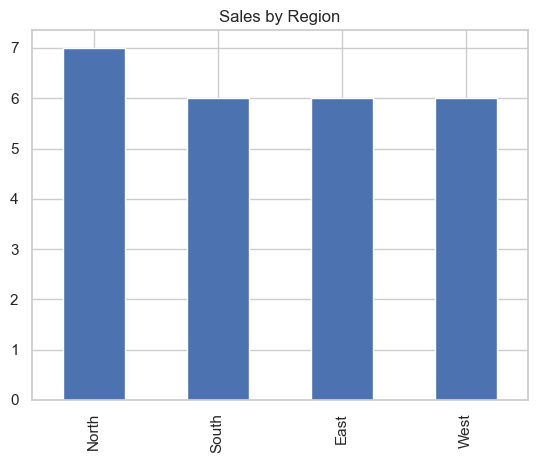

In [8]:

# Bar Chart
df['Region'].value_counts().plot(kind='bar')
plt.title("Sales by Region")
plt.show()


In [ ]:

# Pie Chart
df['ProductCategory'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Product Category Share")
plt.show()


In [ ]:

# Histogram
plt.hist(df['Revenue'], bins=10)
plt.title("Revenue Distribution")
plt.show()


In [ ]:

# Line Graph
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date').plot(x='Date', y='Revenue')
plt.title("Revenue Over Time")
plt.show()


In [ ]:

# Box Plot
sns.boxplot(y=df['Revenue'])
plt.title("Revenue Box Plot")
plt.show()


In [ ]:

# Scatter Plot
plt.scatter(df['MarketingSpend'], df['Revenue'])
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")
plt.title("Marketing Spend vs Revenue")
plt.show()


## 7. Five-Number Summary

In [ ]:

min_val = df['Revenue'].min()
Q1 = df['Revenue'].quantile(0.25)
median = df['Revenue'].median()
Q3 = df['Revenue'].quantile(0.75)
max_val = df['Revenue'].max()

(min_val, Q1, median, Q3, max_val)


## 8. Population vs Sample

In [ ]:

sample = df.sample(10)
sample.describe()


## 9. Variables & Levels of Measurement

In [ ]:

df.dtypes


## Bonus: Correlation Heatmap

In [ ]:

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()
